# Pixel Visualization

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

# Load the image
image_path = "star.jpg"  # Replace with your image path
image = Image.open(image_path)
image = image.resize((100, 100))  # Resize for simplicity
image_array = np.array(image)

# Reshape the image into (num_pixels, 3)
pixels = image_array.reshape(-1, 3)  # Assumes the image is in RGB format 

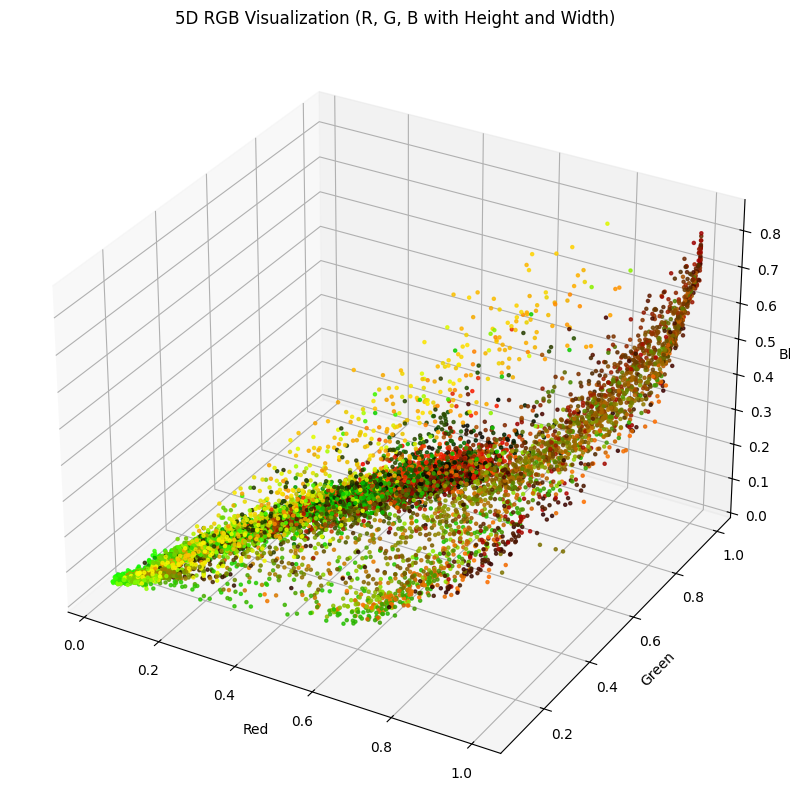

In [71]:
# Get image dimensions
height, width, _ = image_array.shape

# Create a meshgrid for height and width
h, w = np.meshgrid(np.arange(height), np.arange(width))
h = h.flatten()  # Flatten height coordinates
w = w.flatten()  # Flatten width coordinates

# Reshape the image array and extract RGB values
pixels = image_array.reshape(-1, 3)
R, G, B = pixels[:, 0], pixels[:, 1], pixels[:, 2]

# Normalize RGB values to [0, 1] for plotting
R, G, B = R / 255.0, G / 255.0, B / 255.0

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using R, G, B as positions and (h, w) as color
scatter = ax.scatter(R, G, B, c=np.stack([h, w, np.zeros_like(h)]).T / max(h.max(), w.max()), 
                     s=5, marker='o', alpha=0.8)

# Labels and title
ax.set_xlabel("Red")
ax.set_ylabel("Green")
ax.set_zlabel("Blue")
ax.set_title("5D RGB Visualization (R, G, B with Height and Width)")
plt.show()

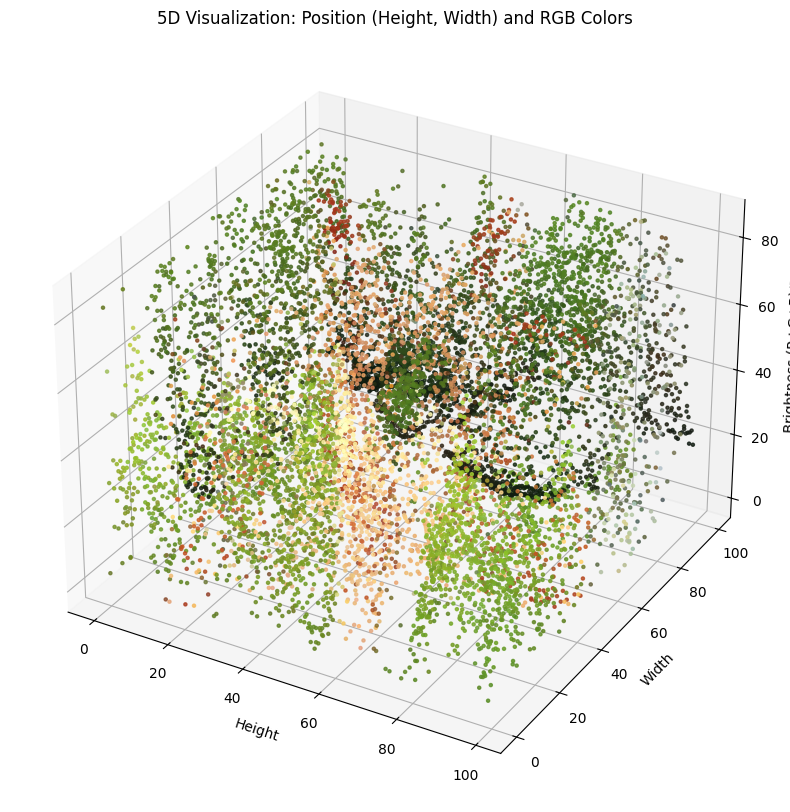

In [72]:
colors = pixels / 255.0 

# Extract RGB channels
R, G, B = pixels[:, 0], pixels[:, 1], pixels[:, 2]

# Create 3D scatter plot: Height (y), Width (x), and Brightness (e.g., sum of RGB)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with height, width, and brightness
brightness = (R + G + B) / 3.0  # Example dimension for z-axis (you can change this)
scatter = ax.scatter(h, w, brightness, c=colors, s=5, marker='o', alpha=0.8)

# Labels and title
ax.set_xlabel("Height")
ax.set_ylabel("Width")
ax.set_zlabel("Brightness (R+G+B)/3")
ax.set_title("5D Visualization: Position (Height, Width) and RGB Colors")

plt.show()

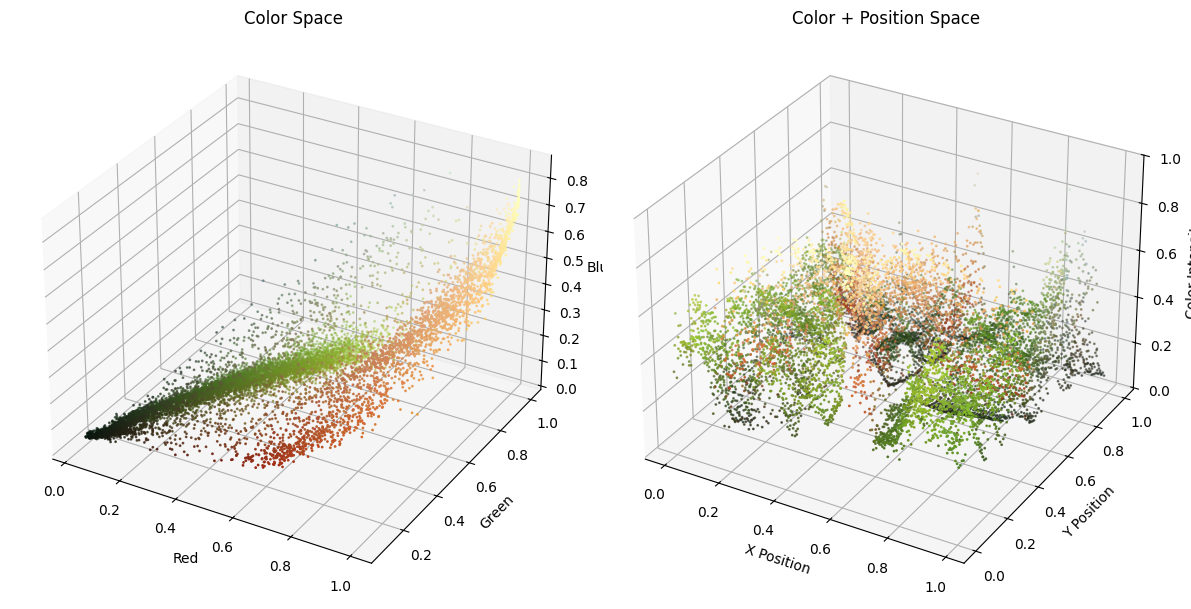

In [73]:
pixels = np.array(image)

# Step 2: Extract RGB values and spatial positions
h, w, _ = pixels.shape
r = pixels[:, :, 0].flatten() / 255.0  # Normalize RGB values to [0, 1]
g = pixels[:, :, 1].flatten() / 255.0
b = pixels[:, :, 2].flatten() / 255.0

x, y = np.meshgrid(range(w), range(h))  # Create X, Y coordinates
x = x.flatten() / w  # Normalize spatial positions to [0, 1]
y = y.flatten() / h

# Step 3: Combine RGB and spatial positions
color_space = np.vstack((r, g, b)).T
color_position_space = np.vstack((r, g, b, x, y)).T

# Step 4: Visualize
fig = plt.figure(figsize=(12, 6))

# Plot "Color Space"
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(r, g, b, c=color_space, s=1)
ax1.set_title("Color Space")
ax1.set_xlabel("Red")
ax1.set_ylabel("Green")
ax1.set_zlabel("Blue")

# Plot "Color + Position Space"
ax2 = fig.add_subplot(122, projection="3d")
color_intensity = (r + g + b) / 3  # Average color intensity
ax2.scatter(x, y, color_intensity, c=color_space, s=1)
ax2.set_title("Color + Position Space")
ax2.set_xlabel("X Position")
ax2.set_ylabel("Y Position")
ax2.set_zlabel("Color Intensity")

plt.tight_layout()
plt.show()

# K-Means

In [74]:
def initialize_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def compute_distances(X, centroids):
    distances = np.zeros((X.shape[0], len(centroids)))
    for i, centroid in enumerate(centroids):
        distances[:, i] = np.linalg.norm(X - centroid, axis=1)
    return distances

def assign_clusters(distances):
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points_in_cluster = X[labels == i]
        if points_in_cluster.size > 0:
            centroids[i] = points_in_cluster.mean(axis=0)
    return centroids

def kmeans(X, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iters):
        old_centroids = centroids
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        centroids = update_centroids(X, labels, k)

        if np.linalg.norm(centroids - old_centroids) < tol:
            break
        
    return labels, centroids

In [75]:
image = cv2.imread('star.jpg')
 
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

x, y = np.meshgrid(range(w), range(h))
x = x.flatten()
y = y.flatten() 

pixel_vals = image.reshape((-1,3))
 
pixel_vals = np.float32(pixel_vals)

In [76]:
from sklearn.metrics import silhouette_score

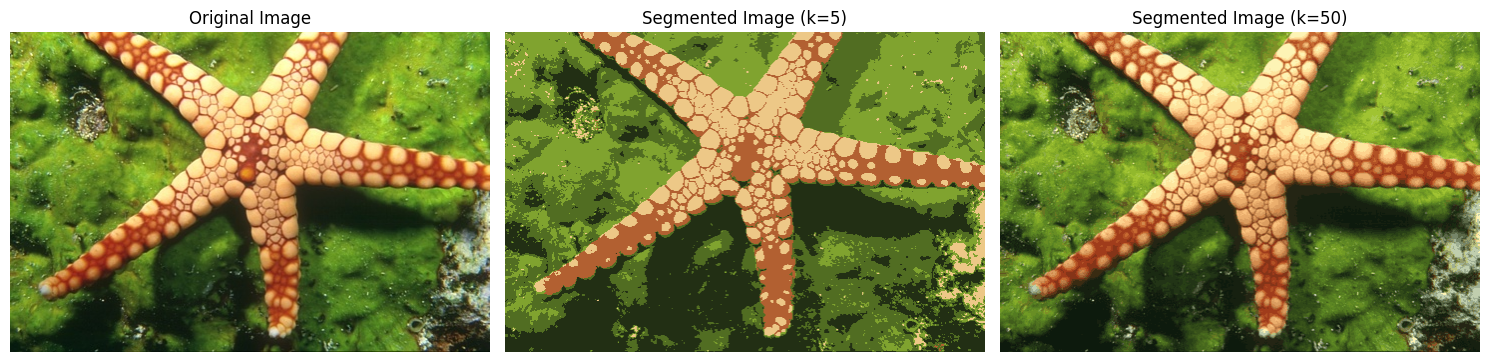

In [ ]:
def segment_image(pixel_vals, k):
    labels, centroids = kmeans(pixel_vals, k)
    centers = np.uint8(centroids)
    segmented_data = centers[labels.flatten()]
    
    segmented_image = segmented_data.reshape((image.shape))
    return segmented_image

segmented_image_k5 = segment_image(pixel_vals, 5)
segmented_image_k50 = segment_image(pixel_vals, 50)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_image_k5)
plt.title("Segmented Image (k=5)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_image_k50)
plt.title("Segmented Image (k=50)")
plt.axis("off")

plt.tight_layout()
plt.show()

# K-Maens with position information

In [26]:
# construct the 5D image constructed from (red, green, blue, x_pixel, y_pixel)

y = y[:, np.newaxis]
x = x[:, np.newaxis]
wheight = 0.7 # add wheight to the information from the position
x = x * wheight
y = y * wheight
D5_image = np.concatenate((pixel_vals, x), axis=1)
D5_image = np.concatenate((D5_image, y), axis=1)

x = x.reshape(-1)
y = y.reshape(-1)

In [69]:
def segment_image_position(pixel_vals, k):
    labels, centroids = kmeans(pixel_vals, k)
    centers = np.uint8(centroids)
    segmented_data = centers[labels.flatten()]
    segmented_data = segmented_data[:, :3]
    segmented_image = segmented_data.reshape(image.shape)
    return segmented_image, segmented_data

segmented_image_5D_k5, segmented_datak5 = segment_image_position(D5_image, 5)
segmented_image_5D_k50, segmented_datak50= segment_image_position(D5_image, 50)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_image_5D_k5)
plt.title("Segmented Image (k=5)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_image_5D_k50)
plt.title("Segmented Image (k=50)")
plt.axis("off")

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

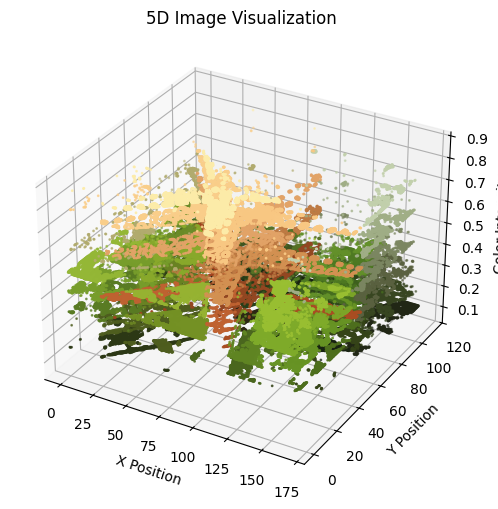

In [31]:
def visualize_5d_image(segmented_image):

    r = segmented_image[:, 0].flatten() / 255.0  # Normalize RGB values to [0, 1]
    g = segmented_image[:, 1].flatten() / 255.0
    b = segmented_image[:, 2].flatten() / 255.0

    color_space = np.vstack((r, g, b)).T  # Combine RGB for color
    color_intensity = (r + g + b) / 3  # Average color intensity

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(x, y, color_intensity, c=color_space, s=1)
    
    ax.set_title("5D Image Visualization")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    ax.set_zlabel("Color Intensity")
    plt.show()

# Call the function with one of your segmented images
visualize_5d_image(segmented_datak50)

# Comparison between 5 clusters with position information and without

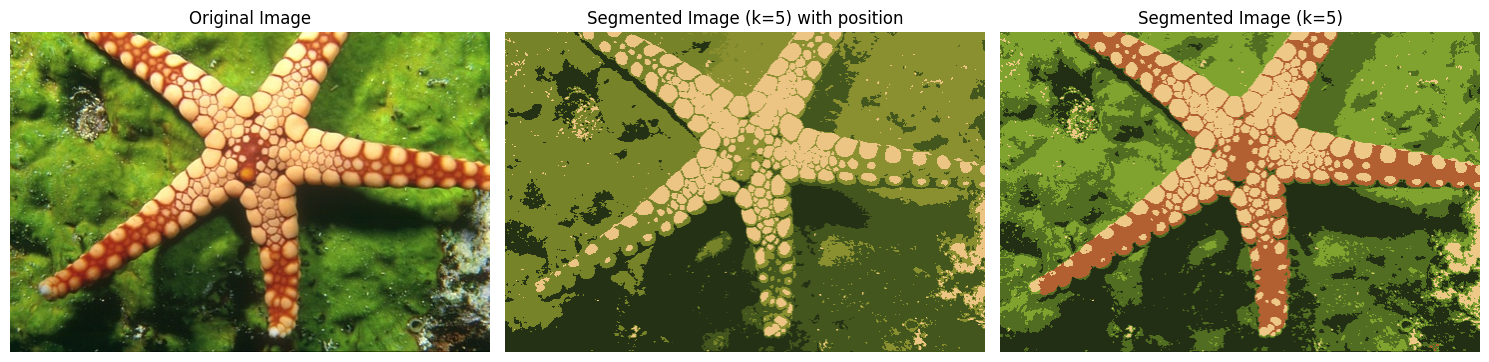

In [32]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_image_5D_k5)
plt.title("Segmented Image (k=5) with position")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_image_k5)
plt.title("Segmented Image (k=5)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Comparison between 50 clusters with position information and without

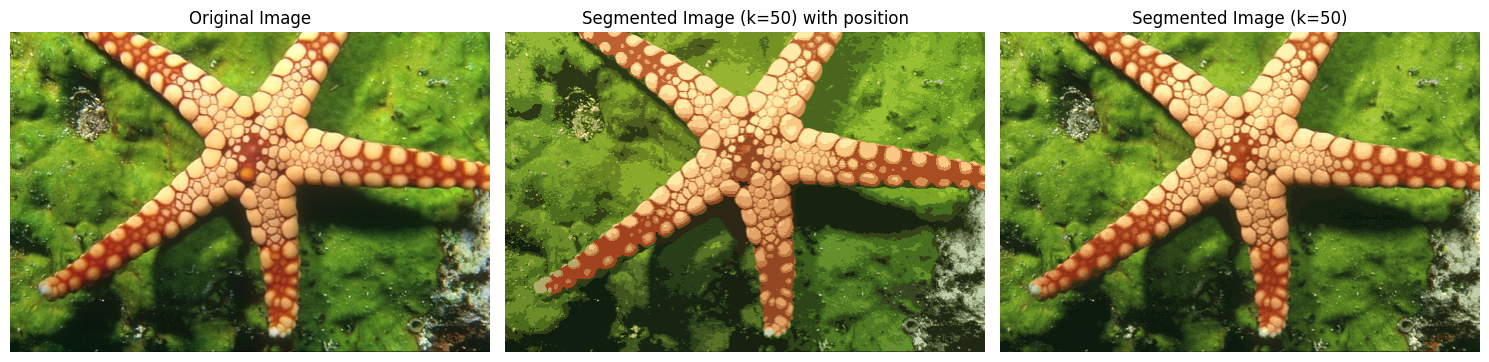

In [33]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_image_5D_k50)
plt.title("Segmented Image (k=50) with position")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmented_image_k50)
plt.title("Segmented Image (k=50)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Agglomerative clustering

#### 1.Start with all points as individual clusters.
#### 2.Find the two closest clusters (based on a distance metric) and merge them.
#### 3.Repeat until all points are clustered into a single hierarchy.

In [34]:
def init_clusters(X):
    clusters = []
    for i, x in enumerate(X):
        clusters.append([1, x, [i]])
    return clusters

def compute_distancesAgg(clusters):
    num_clusters = len(clusters)
    distances = np.zeros((num_clusters, num_clusters))
    
    for i, cluster in enumerate(clusters):
        for j, other_cluster in enumerate(clusters):
            distances[i, j] = np.linalg.norm(
                (cluster[1] / cluster[0]) - (other_cluster[1] / other_cluster[0])
            )
    return distances

def assign_clustersAgg(distances):
    np.fill_diagonal(distances, np.inf)
    closest_pair = np.unravel_index(np.argmin(distances), distances.shape)
    
    return closest_pair

def update_clusters(old_clusters, a_cluster, b_cluster):
    updated_clusters = []
    
    merged_cluster = [
        old_clusters[a_cluster][0] + old_clusters[b_cluster][0],  # Sum of lengths
        old_clusters[a_cluster][1] + old_clusters[b_cluster][1],  # Sum of values
        np.concatenate((old_clusters[a_cluster][2], old_clusters[b_cluster][2])) # concatnate all the items from one cluster to those of the second cluster
    ]
    
    for i, cluster in enumerate(old_clusters):
        if i != a_cluster and i != b_cluster:
            updated_clusters.append(cluster)
    
    updated_clusters.append(merged_cluster)
    
    return updated_clusters

def agglomerative(X, num_clusters=1, max_iters=100):
    clusters = init_clusters(X)
    
    for _ in range(max_iters):
        if len(clusters) <= num_clusters:
            break
        
        distances = compute_distancesAgg(clusters)
        a, b = assign_clustersAgg(distances)
        clusters = update_clusters(clusters, a, b)
    
    return clusters

In [80]:
image = cv2.imread('star.jpg')

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, c = image.shape 

x, y = np.meshgrid(range(w), range(h))
x = x.flatten()
y = y.flatten()

pixel_vals2 = image.reshape((-1, 3))

pixel_vals2 = np.float32(pixel_vals2)

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"pixel_vals2 shape: {pixel_vals2.shape}")
x, y = np.meshgrid(range(w), range(h))
x = x.flatten()
y = y.flatten() 

pixel_vals2 = image.reshape((-1,3))
pixel_vals2 = np.float32(pixel_vals2)

# get the colors
colors, inverse_indices = np.unique(pixel_vals2, axis=0, return_inverse=True)

print(f"unique colors:{colors.shape}")

x shape: (154401,)
y shape: (154401,)
pixel_vals2 shape: (154401, 3)
unique colors:(71166, 3)


image => distinct colors => k similar colors => color clusters => map unique colors <=> cluster colors => image colors

In [81]:
k_colors = kmeans(colors, 100)

In [82]:
color_cluster = agglomerative(k_colors[1], 10)

In [88]:
result_array = np.zeros(k_colors[1].shape)

for num_elements, sum_elements, indices in color_cluster:
    mean_value = (sum_elements / num_elements).astype(int)
    for index in indices:
        result_array[index] = mean_value

# Output the result
print("Resulting array:", result_array.shape)

Resulting array: (100, 3)


In [84]:
centers = np.uint8(result_array)
segmented_data = centers[k_colors[0].flatten()]

In [85]:
result_image  = segmented_data[inverse_indices]

In [86]:
segmented_image = result_image.reshape((image.shape))

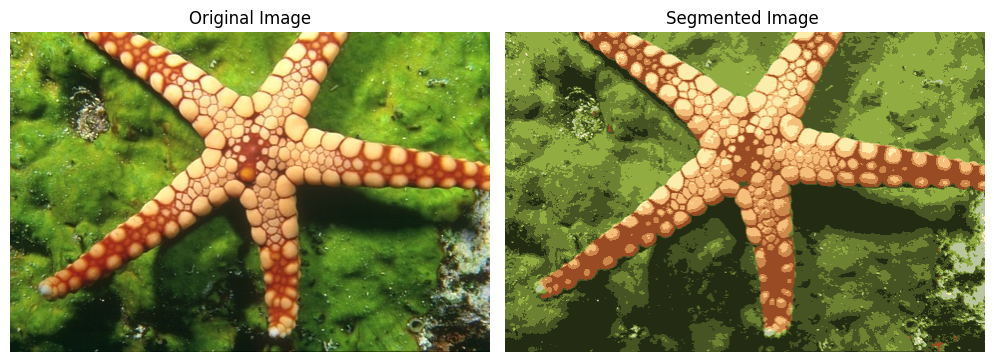

In [87]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_image)
plt.title("Segmented Image ")
plt.axis("off")

plt.tight_layout()
plt.show()

(20, 20, 3)


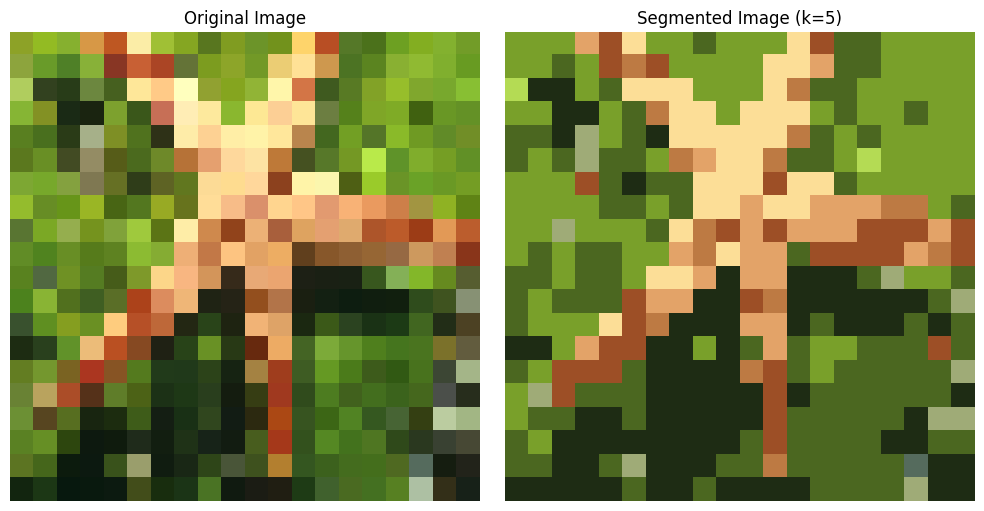

In [ ]:
# simply agglomatative cluster on a 20x20 image 
segmented_image = result_array.reshape(image.shape).astype(np.uint8)
print(segmented_image.shape)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented_image)
plt.title("Segmented Image (k=5)")
plt.axis("off")

plt.tight_layout()
plt.show()